<a href="https://colab.research.google.com/github/llessus/Novas-tecnologias-/blob/main/AT5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória do Dataset Titanic (AT5)

Este notebook resolve as atividades propostas para a avaliação da relação entre variáveis no dataset do Titanic.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")

### 1. Carregar o arquivo train.csv

In [5]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Indicar a quantidade de linhas e colunas do dataset

In [14]:
linhas, colunas = df.shape
print(f"O dataset possui {linhas} linhas e {colunas} colunas.")

O dataset possui 891 linhas e 12 colunas.


### 3. Indicar o tipo de dado de cada variável

In [13]:
print("Tipos de dados de cada variável:\n")
print(df.dtypes)

Tipos de dados de cada variável:

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


### 4. Realizar um resumo estatístico das variáveis

In [12]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### 5. Frequência e Gráfico da variável "Survived" (Sobrevivência)

**Explicação do tipo de gráfico:** Como a variável `Survived` é **categórica** (0 = Não sobreviveu, 1 = Sobreviveu), o tipo de gráfico mais adequado é o **gráfico de barras** (ou *countplot*). Ele nos permite visualizar de forma clara e direta a frequência (contagem absoluta) de cada uma das categorias, facilitando a comparação visual entre a quantidade de pessoas que sobreviveram e as que não sobreviveram.

Tabela de Frequência - Survived:

Survived
0    549
1    342
Name: count, dtype: int64


/tmp/ipykernel_1923/113700668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


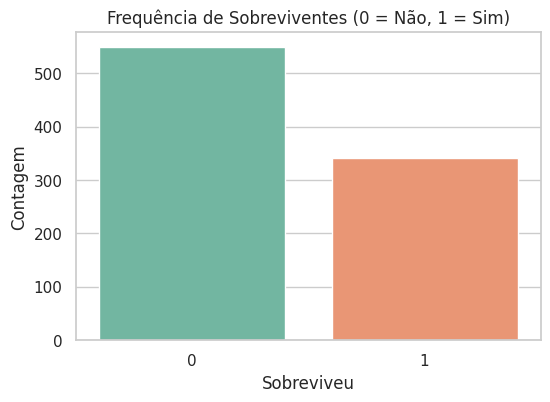

In [7]:
# Tabela de frequência
freq_survived = df['Survived'].value_counts()
print("Tabela de Frequência - Survived:\n")
print(freq_survived)

# Gráfico de barras
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Frequência de Sobreviventes (0 = Não, 1 = Sim)')
plt.xlabel('Sobreviveu')
plt.ylabel('Contagem')
plt.show()

### 6. Quantidade de sobreviventes e a classe mais frequente

In [10]:
# Quantas pessoas sobreviveram?
num_sobreviventes = df['Survived'].sum()
print(f"Total de pessoas que sobreviveram: {num_sobreviventes}")

# Qual a classe mais frequente?
classe_frequente = df['Pclass'].mode()[0]
print(f"A classe mais frequente (Pclass) é a classe: {classe_frequente}")

Total de pessoas que sobreviveram: 342
A classe mais frequente (Pclass) é a classe: 3


### 7. Relação entre "Sex" e "Survived"

Tabela de Frequência (Sexo vs Sobrevivência):

Survived    0    1
Sex               
female     81  233
male      468  109


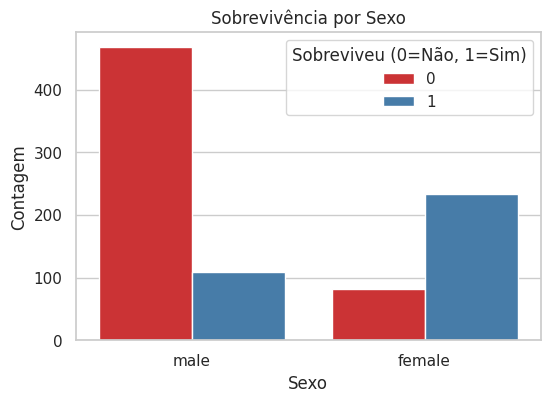


Taxa de sobrevivência entre mulheres: 74.20%
Taxa de sobrevivência entre homens: 18.89%

Resposta: Sim, a proporção de mulheres que sobreviveram (aprox. 74%) foi significativamente maior do que a de homens (aprox. 19%).


In [9]:
# Tabela de frequência cruzada (crosstab)
freq_sex_survived = pd.crosstab(df['Sex'], df['Survived'])
print("Tabela de Frequência (Sexo vs Sobrevivência):\n")
print(freq_sex_survived)

# Gráfico
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title('Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Contagem')
plt.legend(title='Sobreviveu (0=Não, 1=Sim)')
plt.show()

# Mulheres sobreviveram mais que homens?
taxa_sobrevivencia_mulheres = df[df['Sex'] == 'female']['Survived'].mean()
taxa_sobrevivencia_homens = df[df['Sex'] == 'male']['Survived'].mean()

print(f"\nTaxa de sobrevivência entre mulheres: {taxa_sobrevivencia_mulheres:.2%}")
print(f"Taxa de sobrevivência entre homens: {taxa_sobrevivencia_homens:.2%}")
print("\nResposta: Sim, a proporção de mulheres que sobreviveram (aprox. 74%) foi significativamente maior do que a de homens (aprox. 19%).")

### 8. Distribuição das idades dos passageiros

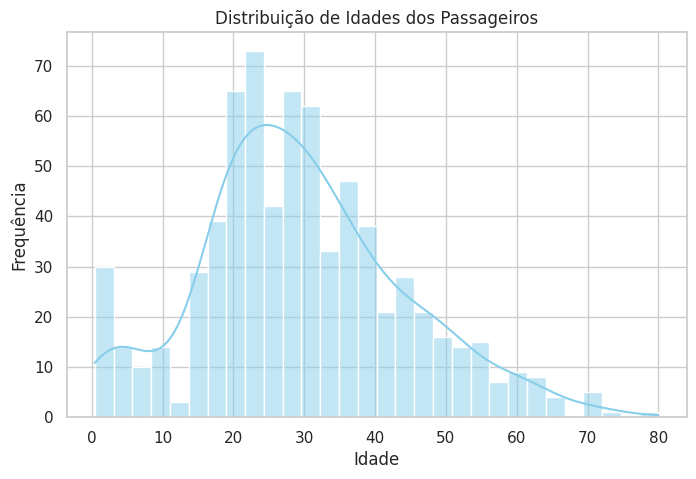

Média de idade: 29.70 anos
Mediana de idade: 28.00 anos
Coeficiente de assimetria (Skewness): 0.39

Análise da Distribuição:
- Simetria: A distribuição NÃO é perfeitamente simétrica. Como podemos ver pelo gráfico e pela leve assimetria positiva (0.39), ela é enviesada à direita, indicando que há passageiros mais velhos que puxam a cauda do gráfico para a direita.
- Maioria jovem ou idosa: A grande maioria dos passageiros era jovem. A maior concentração de idades ocorre entre os 20 e 35 anos, além de haver um pico considerável de crianças muito pequenas (abaixo de 5 anos).


In [11]:
# Gráfico da distribuição das idades (Histograma)
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue', bins=30)
plt.title('Distribuição de Idades dos Passageiros')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

# Análise estatística da idade
media_idade = df['Age'].mean()
mediana_idade = df['Age'].median()
assimetria = df['Age'].skew()

print(f"Média de idade: {media_idade:.2f} anos")
print(f"Mediana de idade: {mediana_idade:.2f} anos")
print(f"Coeficiente de assimetria (Skewness): {assimetria:.2f}")
print("\nAnálise da Distribuição:")
print("- Simetria: A distribuição NÃO é perfeitamente simétrica. Como podemos ver pelo gráfico e pela leve assimetria positiva (0.39), ela é enviesada à direita, indicando que há passageiros mais velhos que puxam a cauda do gráfico para a direita.")
print("- Maioria jovem ou idosa: A grande maioria dos passageiros era jovem. A maior concentração de idades ocorre entre os 20 e 35 anos, além de haver um pico considerável de crianças muito pequenas (abaixo de 5 anos).")